In [8]:
import random
from datetime import datetime, timedelta

# Configurações
inicio = datetime(2025, 5, 16, 12, 0)
num_amostras = 60
dados = []

for i in range(num_amostras):
    timestamp = inicio + timedelta(minutes=i)
    medida1 = round(random.uniform(0, 5), 2)  # por exemplo, tensão 0 a 5V
    medida2 = round(random.uniform(10, 100), 2)  # corrente mA
    medida3 = round(random.uniform(20, 30), 2)  # temperatura °C
    medida4 = round(random.uniform(0, 1), 2)    # valor normalizado

    dados.append([timestamp.strftime("%Y-%m-%d %H:%M"), medida1, medida2, medida3, medida4])

# Exibindo as 5 primeiras linhas
for linha in dados[:5]:
    print(linha)


['2025-05-16 12:00', 0.32, 22.0, 28.71, 0.15]
['2025-05-16 12:01', 3.28, 69.59, 23.0, 0.21]
['2025-05-16 12:02', 3.61, 34.73, 22.0, 0.84]
['2025-05-16 12:03', 2.47, 12.17, 25.41, 0.29]
['2025-05-16 12:04', 1.94, 73.43, 23.13, 0.83]


In [9]:
import numpy as np
from datetime import datetime, timedelta

# Exemplo de dados: [timestamp, m1, m2, m3, m4]


# Converte timestamp para datetime
for linha in dados:
    linha[0] = datetime.strptime(linha[0], "%Y-%m-%d %H:%M")

# Parâmetros
intervalo_integracao = timedelta(minutes=15)

# Inicializações
dados_integrados = []
inicio_janela = dados[0][0]
janela = []

for linha in dados:
    timestamp, medidas = linha[0], linha[1:]

    if timestamp < inicio_janela + intervalo_integracao:
        janela.append(medidas)
    else:
        # Integração: soma das medidas na janela (pode ser área, média, etc)
        soma = np.sum(janela, axis=0)  # integração simples por soma
        dados_integrados.append([inicio_janela] + soma.tolist())

        # Nova janela
        inicio_janela = timestamp
        janela = [medidas]

# Última janela (caso não tenha fechado certinho)
if janela:
    soma = np.sum(janela, axis=0)
    dados_integrados.append([inicio_janela] + soma.tolist())

# Exibindo dados integrados
for linha in dados_integrados:
    print(linha)

print(dados_integrados)

[datetime.datetime(2025, 5, 16, 12, 0), 31.49, 828.7399999999998, 369.46000000000004, 8.509999999999998]
[datetime.datetime(2025, 5, 16, 12, 15), 39.78000000000001, 675.1800000000001, 371.78999999999996, 5.73]
[datetime.datetime(2025, 5, 16, 12, 30), 36.900000000000006, 942.9800000000001, 351.1700000000001, 5.41]
[datetime.datetime(2025, 5, 16, 12, 45), 30.35, 777.6600000000001, 396.71000000000004, 6.26]
[[datetime.datetime(2025, 5, 16, 12, 0), 31.49, 828.7399999999998, 369.46000000000004, 8.509999999999998], [datetime.datetime(2025, 5, 16, 12, 15), 39.78000000000001, 675.1800000000001, 371.78999999999996, 5.73], [datetime.datetime(2025, 5, 16, 12, 30), 36.900000000000006, 942.9800000000001, 351.1700000000001, 5.41], [datetime.datetime(2025, 5, 16, 12, 45), 30.35, 777.6600000000001, 396.71000000000004, 6.26]]


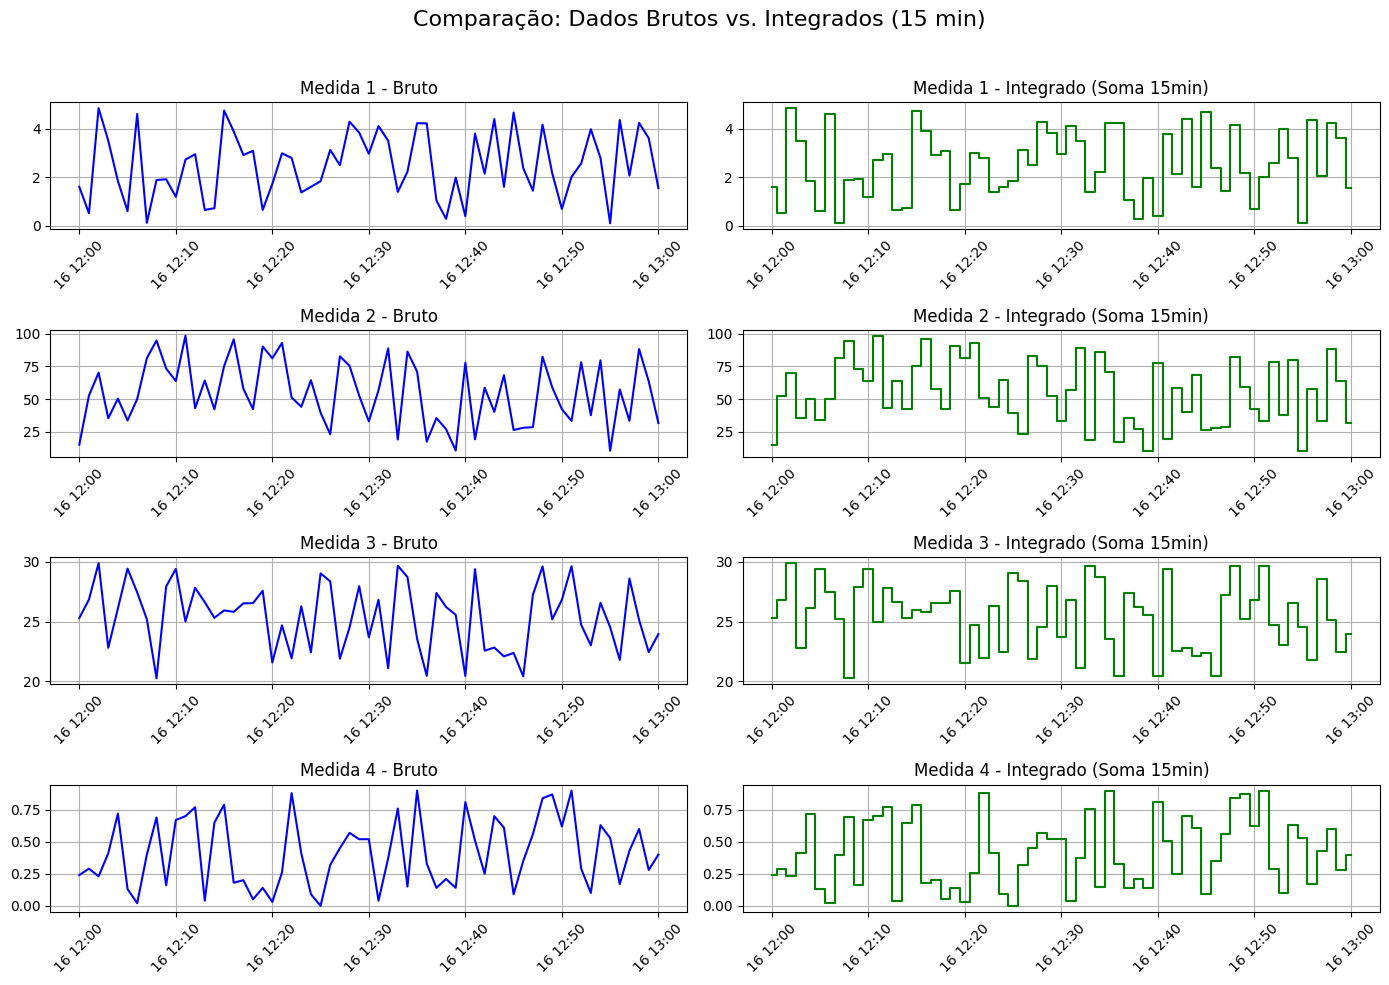

In [14]:
import random
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# 1. Gerar 60 dados simulados (1 amostra por minuto)
inicio = datetime(2025, 5, 16, 12, 0)
num_amostras = 61
dados = []

for i in range(num_amostras):
    timestamp = inicio + timedelta(minutes=i)
    medida1 = round(random.uniform(0, 5), 2)   # Ex: Tensão
    medida2 = round(random.uniform(10, 100), 2)  # Corrente
    medida3 = round(random.uniform(20, 30), 2)  # Temperatura
    medida4 = round(random.uniform(0, 1), 2)    # Normalizado
    dados.append([timestamp, medida1, medida2, medida3, medida4])

# 2. Integração por janelas de 15 minutos (15 amostras)
janela_tempo = 1  # minutos = 15 amostras se 1 por minuto
dados_integrados = []

for i in range(0, len(dados), janela_tempo):
    bloco = dados[i:i+janela_tempo]
    if bloco:
        ts_inicio = bloco[0][0]
        medidas = np.array([linha[1:] for linha in bloco])
        soma = np.sum(medidas, axis=0)
        dados_integrados.append([ts_inicio] + soma.tolist())

# 3. Preparar dados para gráfico
timestamps_raw = [linha[0] for linha in dados]
valores_raw = np.array([linha[1:] for linha in dados])

timestamps_int = [linha[0] for linha in dados_integrados]
valores_int = np.array([linha[1:] for linha in dados_integrados])

# 4. Plotar gráficos
nomes_medidas = ["Medida 1", "Medida 2", "Medida 3", "Medida 4"]
fig, axs = plt.subplots(4, 2, figsize=(14, 10))
fig.suptitle("Comparação: Dados Brutos vs. Integrados (15 min)", fontsize=16)

for i in range(4):
    # Dados brutos
    axs[i, 0].plot(timestamps_raw, valores_raw[:, i], label="Bruto", color="blue")
    axs[i, 0].set_title(f"{nomes_medidas[i]} - Bruto")
    axs[i, 0].tick_params(axis='x', rotation=45)
    axs[i, 0].grid(True)

    # Dados integrados
    axs[i, 1].step(timestamps_int, valores_int[:, i], label="Integrado", color="green", where='mid')
    axs[i, 1].set_title(f"{nomes_medidas[i]} - Integrado (Soma 15min)")
    axs[i, 1].tick_params(axis='x', rotation=45)
    axs[i, 1].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
